<a href="https://colab.research.google.com/github/wtryab-re/machine-learning-reboost/blob/main/simple_logistic_regression_end2end.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import n Install

In [ ]:
!pip install matplotlib seaborn pandas numpy scikit-learn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

Import Dataset

In [14]:
df = pd.read_csv("/content/placement.csv")
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


Dataset Desc

In [15]:
df.shape

(1000, 3)

In [16]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


Preprocessing -- missing values handling, handle outliers


In [ ]:
#This is already preprocessed with missing values handling

Separate Input Features and Output

In [27]:
x = df.drop(columns="placed")
y= df["placed"]

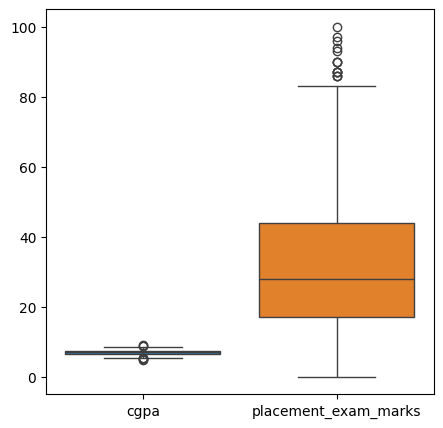

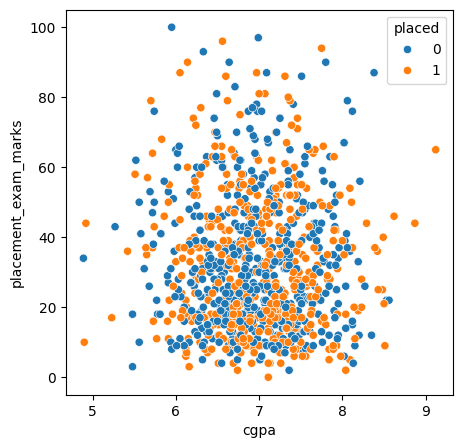

In [30]:
#what the dataset looks like
plt.figure(figsize=(5,5))
sns.boxplot(data=x)
plt.show()
plt.figure(figsize=(5,5))
sns.scatterplot(data=df, x="cgpa", y="placement_exam_marks", hue="placed")
plt.show()

Import model and train_test_split

In [33]:
from sklearn.model_selection import train_test_split

Train Test Data Split

In [38]:
trainX, testX, trainY, testY = train_test_split(x,y,train_size=0.6, random_state=42)

Scaling Values

Scaling values (normalization/standardization) brings all numerical features to a common range, preventing variables with large magnitudes from dominating those with small magnitudes. This ensures equal treatment of features, speeds up optimization convergence for gradient-based models (e.g., linear regression, neural networks), and improves accuracy for distance-based algorithms

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()

In [43]:
#fit_transform understands the data, calculates the necessary statistics (fit) and then applies the scaling transformation (transform) to the dataset in a single step
trainX = scaler.fit_transform(trainX)
testX = scaler.transform(testX)
#this gives numpy array as a result so need to convert back to dataframe

In [47]:
X_train = pd.DataFrame(trainX, columns=x.columns)
X_test = pd.DataFrame(testX, columns=x.columns)

,cgpa,placement_exam_marks
0,-0.817229,-1.089882
1,-0.464505,-1.292918
2,-0.229355,-0.937605
3,0.123370,2.463253
4,-0.380523,-0.531532


Training

In [48]:
from sklearn.linear_model import LogisticRegression

In [50]:
model = LogisticRegression()

In [51]:
model.fit(X_train, trainY)

LogisticRegression()

Test

In [54]:
prediction = model.predict(X_test)

Evaluate

In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [58]:
accuracy_score(testY, prediction)

0.535

In [59]:
confusion_matrix(testY, prediction)

array([[113,  96],
       [ 90, 101]])

In [61]:
print(classification_report(testY,prediction))

              precision    recall  f1-score   support

           0       0.56      0.54      0.55       209
           1       0.51      0.53      0.52       191

    accuracy                           0.54       400
   macro avg       0.53      0.53      0.53       400
weighted avg       0.54      0.54      0.54       400



See Decision Boundary

In [ ]:
#decision boundary library basically shows the function the LR model selected as a decision boundary for placed yes or no

In [62]:
from mlxtend.plotting import plot_decision_regions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

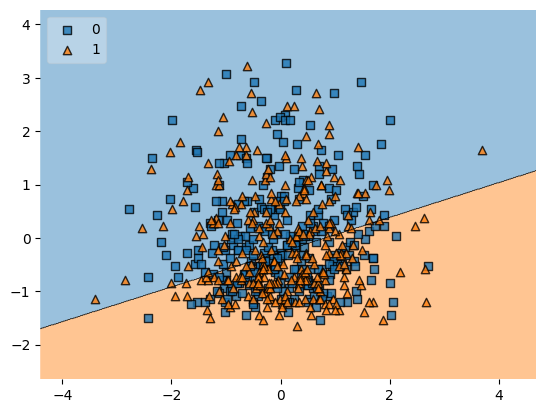

In [63]:
#This function takes numpy arrays as parameter
plot_decision_regions(trainX, trainY.values, clf=model, legend=2)

Exporting a Model for use

In [64]:
import pickle

In [65]:
pickle.dump(model, open("model.pkl", "wb"))

Deploy Model

To deploy a model on cloud, there are plenty platforms but I'll focus on AWS since that is something I've seen in job adverts